# Каталог: EDA актуального пайплайна

**Архитектура production-пайплайна:**
* **Визуальная ветка:** RT-DETR (детекция) → SigLIP 2 + PCA-whitening (эмбеддинги) → FAISS (векторный поиск)
* **Текстовая ветка:** OCR PaddleOCR
* **Матчинг и реранжирование:** XFeat/RANSAC (проверка геометрии) и CatBoost (финальная агрегация признаков)

In [1]:
from pathlib import Path
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from wine_scanner.embed import load_image
from wine_scanner.index import VectorIndex

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
plt.rcParams['figure.dpi'] = 110

def read_jsonl(relative):
    path = ROOT / relative
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line] if path.exists() else []

def image_path(slug):
    return ROOT / 'data/catalog/originals' / f'{slug}.png'


g:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Полнота и состав каталога

,Значение
Всего карточек,2103
С доступным эталоном,2103
Без эталона,0
Опубликовано на сайте,2037
Количество виноделен,135


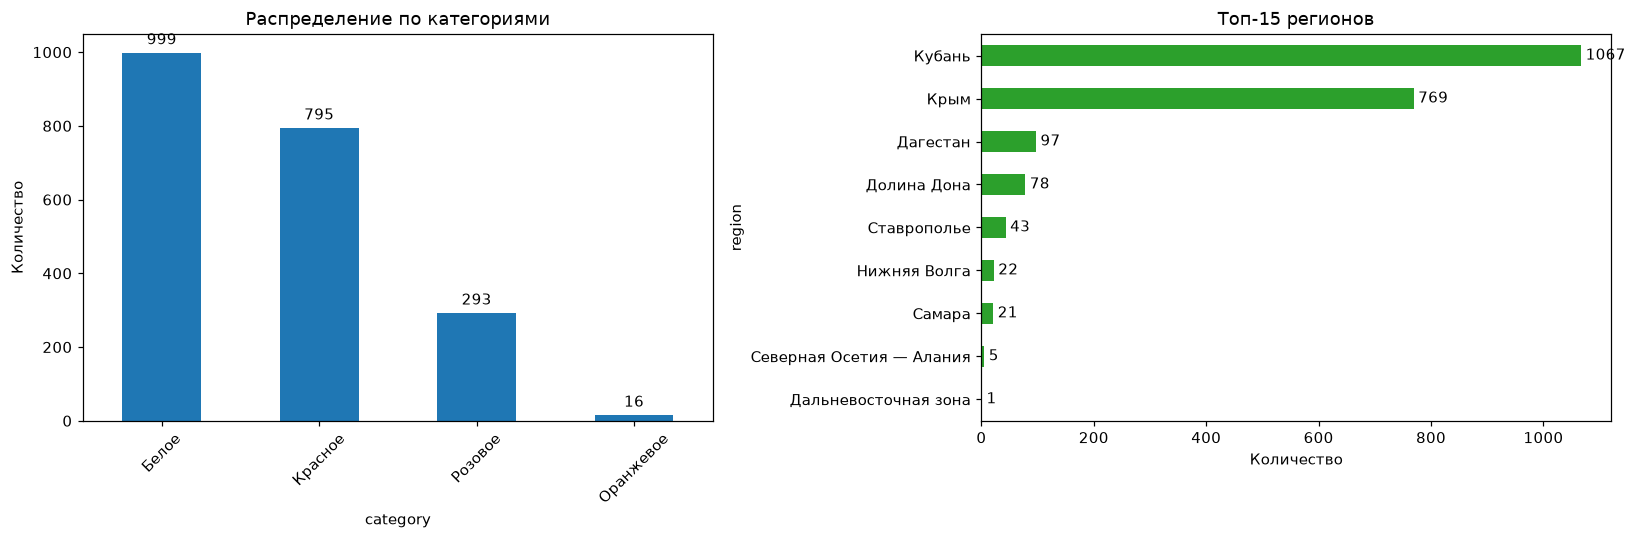

In [2]:
# Загрузка данных
catalog = pd.read_csv(ROOT / 'data/catalog/catalog.csv')

# Подсчет метрик качества
quality = pd.Series({
    'Всего карточек': len(catalog),
    'С доступным эталоном': catalog.source_file.notna().sum(),
    'Без эталона': catalog.source_file.isna().sum(),
    'Опубликовано на сайте': catalog.on_site.fillna(False).sum(),
    'Количество виноделен': catalog.winery.nunique(),
})
display(quality.rename('Значение').to_frame())

# Настройка визуализации
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# График 1: Категории
cat_counts = catalog.category.fillna('Не указано').value_counts()
cat_plot = cat_counts.plot.bar(ax=axes[0], color='#1f77b4', title='Распределение по категориями')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)
for container in cat_plot.containers:
    cat_plot.bar_label(container, padding=3)

# График 2: Топ-15 регионов
reg_counts = catalog.region.fillna('Не указано').value_counts().head(15).sort_values()
reg_plot = reg_counts.plot.barh(ax=axes[1], color='#2ca02c', title='Топ-15 регионов')
axes[1].set_xlabel('Количество')
for container in reg_plot.containers:
    reg_plot.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Выводы по составу каталога

1. **Обоснование Retrieval-архитектуры:** Объем каталога (2103 позиции) и его динамическая природа делают классическую закрытую классификацию нецелесообразной. Каталог работает как поисковая база: при появлении нового товара (slug) его эмбеддинг просто добавляется в FAISS-индекс, что избавляет от необходимости переобучать нейросети.
2. **Идеальное покрытие эталонами:** На данный момент достигнута 100% обеспеченность визуальными референсами — карточек без эталонов нет (0 из 2103). Это критически важно, так как отсутствие картинки формирует жесткий потолок качества для визуальной ветки (поиск был бы возможен только по OCR).
3. **Дисбаланс классов:** В данных наблюдается естественный перевес в сторону белых и красных вин, а географически доминируют Кубань и Крым. 
4. **Вектор развития:** Учитывая выбранную архитектуру и текущую полноту базы, главное внимание при ревизии каталога должно уделяться не сбору недостающих картинок, а **борьбе с дубликатами** и **различению sibling-линеек** (похожих вин от одной винодельни, где ключевую роль играет связка OCR и CatBoost).

## 2. Siblings, общие фото и семантические дубликаты

В этом разделе мы анализируем визуальные и семантические коллизии в каталоге.
Особое внимание уделяется **sibling-линейкам** — винам от одного производителя с идентичным дизайном этикетки, которые отличаются лишь текстом (сорт винограда, год урожая). Мы нормализуем названия (убираем винтажи и лишние пробелы), чтобы сгруппировать такие товары и оценить масштаб проблемы.

,Значение
Товаров (slug) в sibling-группах,196
Уникальных sibling-групп,90
Товаров с shared_photo (общая студийная съемка),26
Товаров с shared_image (байт-в-байт дубликат),55


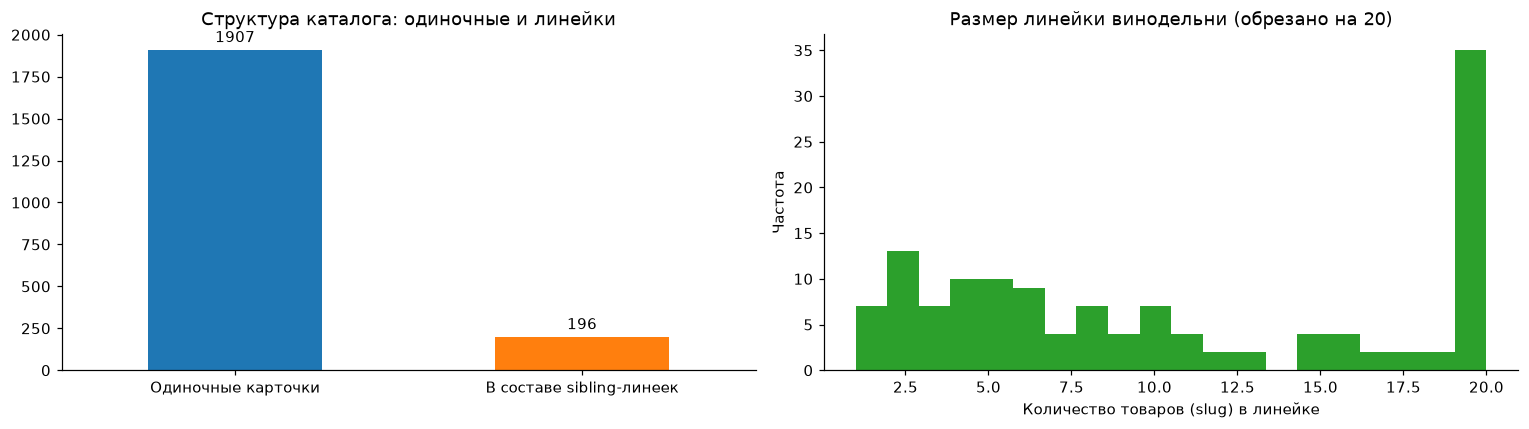

In [3]:
# Нормализация названий: приводим к нижнему регистру, удаляем винтажи (2000-2039) и лишние пробелы
catalog['name_norm'] = (catalog.name.fillna('').str.lower()
                        .str.replace(r'[, ]*20[0-3][0-9]', '', regex=True)
                        .str.replace(r'\s+', ' ', regex=True).str.strip())

# Определение sibling-линеек (одна винодельня + одинаковое базовое название)
family_size = catalog.groupby(['winery', 'name_norm']).slug.transform('size')
siblings = catalog[family_size > 1].copy()

# Сводка по дубликатам и линейкам
duplicate_summary = pd.Series({
    'Товаров (slug) в sibling-группах': len(siblings),
    'Уникальных sibling-групп': siblings.groupby(['winery', 'name_norm']).ngroups,
    'Товаров с shared_photo (общая студийная съемка)': catalog.shared_photo.fillna(False).sum(),
    'Товаров с shared_image (байт-в-байт дубликат)': catalog.shared_image.fillna(False).sum(),
})
display(duplicate_summary.rename('Значение').to_frame())

# Настройка визуализации
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# График 1: Одиночные vs Линейки
counts = pd.Series({'Одиночные карточки': (family_size == 1).sum(), 
                    'В составе sibling-линеек': (family_size > 1).sum()})
bar_plot = counts.plot.bar(ax=axes[0], color=['#1f77b4', '#ff7f0e'], title='Структура каталога: одиночные и линейки')
axes[0].tick_params(axis='x', rotation=0)
for container in bar_plot.containers:
    bar_plot.bar_label(container, padding=3)

# График 2: Гистограмма размера линеек
catalog.groupby('winery').size().clip(upper=20).plot.hist(
    bins=20, ax=axes[1], color='#2ca02c', title='Размер линейки винодельни (обрезано на 20)'
)
axes[1].set_xlabel('Количество товаров (slug) в линейке')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

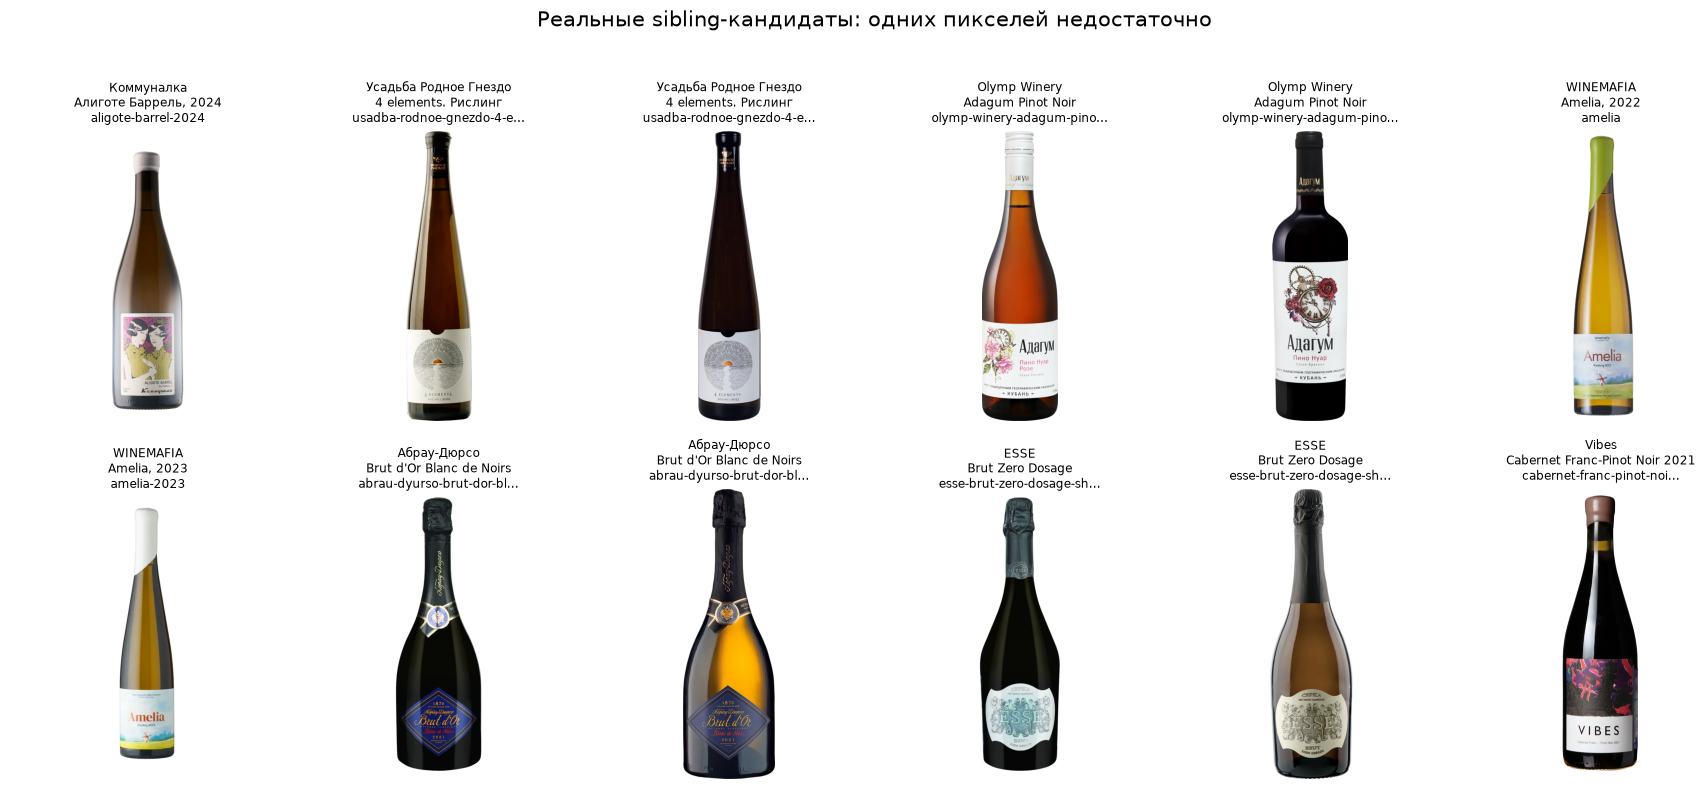

In [4]:

# Отбираем примеры реальных sibling-кандидатов (с доступными картинками)
valid_siblings = siblings[siblings.slug.map(lambda x: image_path(x).exists())]
examples = valid_siblings.groupby('winery').head(2).head(12)

if not examples.empty:
    fig, axes = plt.subplots(2, 6, figsize=(16, 7))
    axes = axes.flat
    
    for axis, row in zip(axes, examples.itertuples()):
        axis.imshow(load_image(image_path(row.slug)))
        axis.axis('off')
        
        # Сокращаем длинные slug для аккуратного отображения
        slug_short = f"{row.slug[:24]}..." if len(row.slug) > 24 else row.slug
        axis.set_title(f'{row.winery}\n{row.name}\n{slug_short}', fontsize=8)
    
    # Отключаем пустые оси
    for axis in axes[len(examples):]: 
        axis.axis('off')
        
    plt.suptitle('Реальные sibling-кандидаты: одних пикселей недостаточно', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

### Парный аудит sibling-кандидатов

Ниже показаны именно две карточки одной пары, а не случайные бутылки общего производителя.
Причина объединения подписана: shared image означает байт-в-байт одинаковый эталон, а
«одинаковое имя + винодельня» — только гипотеза визуальной похожести, которую проверяем
глазами по двум этикеткам.

,Причина пары,Винодельня,Название слева,Slug слева,Название справа,Slug справа
0,shared_image: байт-в-байт один эталон,Вилла Уркуста,Каберне совиньон Классик,villa-urkusta-kaberne-sovinon-klassik-krasnoe-...,Каберне совиньон Классик,villa-urkusta-kaberne-sovinon-klassik-krasnoe-...
1,shared_image: байт-в-байт один эталон,Агролайн,Heritage Dg Skin Contact Red,agrolayn-heritage-dg-skin-contact-red-saperavi...,Heritage DG Skin contact Rkatsiteli,agrolayn-heritage-dg-skin-contact-rkatsiteli-r...
2,shared_image: байт-в-байт один эталон,Oxana Istratova Wine,Ркацители 2023,oxana-istratova-wine-rkatsiteli-2023-oranzhevo...,Ркацители 2024,oxana-istratova-wine-rkatsiteli-2024-oranzhevo...
3,shared_image: байт-в-байт один эталон,ESSE,Demi-Sec Muscat Nectar,esse-demi-sec-muscat-nectar-muskat-belyy-beloe...,Muskat,esse-muskat-muskat-belyy-beloe-ekstra-bryut-115
4,shared_image: байт-в-байт один эталон,Oxana Istratova Wine,Вионье 2023,oxana-istratova-wine-vione-2023-oranzhevoe-suh...,Вионье 2024,oxana-istratova-wine-vione-2024-oranzhevoe-suh...
5,shared_image: байт-в-байт один эталон,Винодельня Братьев Мельниковых,"Кокур Сухое, 2025",kokur-suhoe-2025,"Кокур, 2025",kokur-2025
6,shared_image: байт-в-байт один эталон,Belmas Winery,Pn,belmas-winery-pn-pino-nuar-krasnoe-suhoe-135,Vi,belmas-winery-vi-vione-beloe-suhoe-122
7,shared_image: байт-в-байт один эталон,AGORA WINERY,Agora Yachting Cabernet Sauvignon,agora-yachting-cabernet-sauvignon,Agora Yachting Sauvignon,agora-yachting-sauvignon


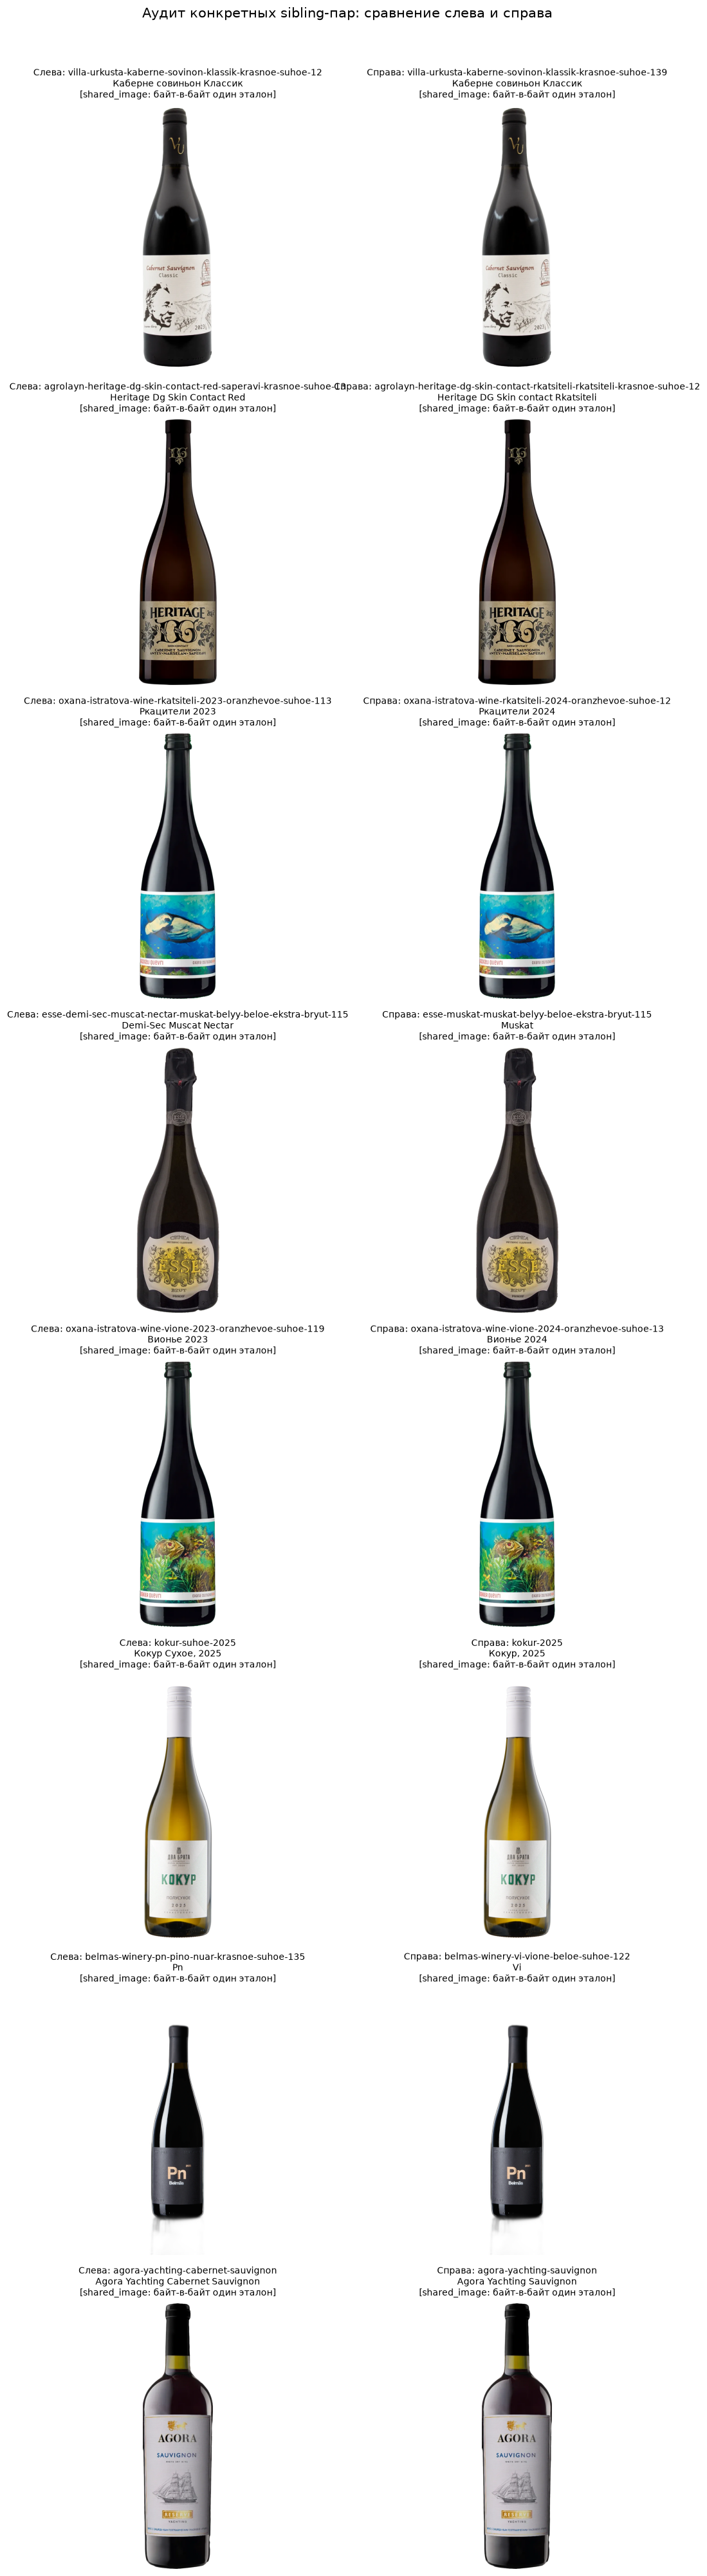

In [5]:
# Строим ПАРЫ для детального аудита.
# 1. Идентичные по image_md5 (байт-в-байт дубликаты эталонов)
# 2. Разные файлы, но одинаковое название внутри одной винодельни

pairs = []
used = set()
with_image = catalog[catalog.slug.map(lambda slug: image_path(slug).exists())].copy()

# 1. Поиск абсолютных дубликатов изображений
for _, group in with_image[with_image.shared_image.fillna(False)].groupby('image_md5'):
    if len(group) >= 2:
        left, right = group.iloc[0], group.iloc[1]
        key = tuple(sorted((left.slug, right.slug)))
        if key not in used:
            used.add(key)
            pairs.append({
                'reason': 'shared_image: байт-в-байт один эталон',
                'left': left, 'right': right
            })

# 2. Поиск семантических дубликатов (одно имя, разные файлы)
for _, group in siblings.groupby(['winery', 'name_norm']):
    group = group[group.slug.map(lambda slug: image_path(slug).exists())]
    if len(group) >= 2 and group.image_md5.nunique(dropna=True) >= 2:
        left, right = group.iloc[0], group.iloc[1]
        key = tuple(sorted((left.slug, right.slug)))
        if key not in used:
            used.add(key)
            pairs.append({
                'reason': 'одинаковое имя + винодельня, разные файлы',
                'left': left, 'right': right
            })

# Ограничиваем вывод и формируем таблицу
pairs = pairs[:8]

if pairs:
    pair_table = pd.DataFrame([{
        'Причина пары': pair['reason'],
        'Винодельня': pair['left'].winery,
        'Название слева': pair['left']['name'],
        'Slug слева': pair['left'].slug,
        'Название справа': pair['right']['name'],
        'Slug справа': pair['right'].slug,
    } for pair in pairs])
    display(pair_table)

    # Визуализация пар
    fig, axes = plt.subplots(len(pairs), 2, figsize=(12, 4.5 * len(pairs)), squeeze=False)
    for row_axes, pair in zip(axes, pairs):
        for axis, card, side in zip(row_axes, (pair['left'], pair['right']), ('Слева', 'Справа')):
            axis.imshow(load_image(image_path(card.slug)))
            axis.axis('off')
            
            # Добавляем отступы, чтобы текст не перекрывал картинку
            title = f"{side}: {card.slug}\n{card['name']}\n[{pair['reason']}]"
            axis.set_title(title, fontsize=9, pad=8)
            
    plt.suptitle('Аудит конкретных sibling-пар: сравнение слева и справа', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Нет пар с двумя доступными эталонами для отображения.')

### Выводы по Sibling-линейкам и дубликатам

Анализ данных подтверждает наличие значительного количества визуальных коллизий. В каталоге присутствует 196 карточек (slug), которые входят в 90 различных sibling-групп. Кроме того, обнаружено 55 товаров с полным дублированием эталонного изображения (байт-в-байт совпадение). 

Визуальный аудит показывает, что вина внутри одной линейки часто имеют абсолютно идентичный дизайн этикетки. В таких ситуациях базовый поиск по визуальному сходству (Visual nearest-neighbour) способен найти правильного производителя или общую линейку, но физически не может выбрать конкретный slug, так как разница заключается только в мелком тексте (например, сорт винограда или год урожая).

**Архитектурное решение:** Совпадение картинки не может быть самостоятельным основанием для выдачи ответа. Именно поэтому пайплайн требует обязательного подключения OCR, модуля проверки текстовых признаков (различающие слова) и sibling guard, которые фильтруют визуальные сходства на основе реального текста на этикетке.

## 3. Качество эталонных изображений

Разрешение и качество эталонных картинок — критический фактор для корректной работы пайплайна. Алгоритмы детекции бутылки (RT-DETR) и, что еще важнее, модуль распознавания текста (OCR) напрямую зависят от детализации этикетки в базе. В этом разделе мы оцениваем физические размеры загруженных изображений и выявляем товары из «зоны риска».

Статистика размеров эталонных изображений (в пикселях):


,count,mean,std,min,25%,50%,75%,max
width,2103.0,762.0,798.0,116.0,271.0,336.0,1024.0,6337.0
height,2103.0,1739.0,1359.0,357.0,1000.0,1080.0,2000.0,9506.0


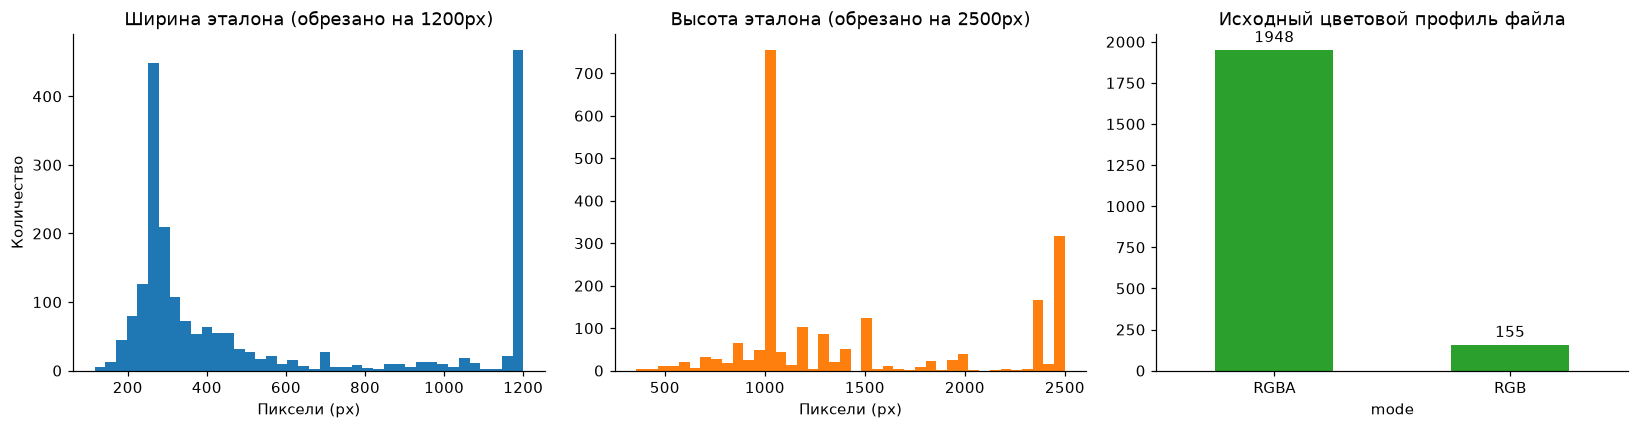

In [7]:
# Отбираем только те записи, для которых физически существует файл изображения
refs = catalog[catalog.slug.map(lambda x: image_path(x).exists())].copy()

print("Статистика размеров эталонных изображений (в пикселях):")
display(refs[['width', 'height']].describe().round(0).T)

# Настройка визуализации
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# График 1: Ширина
refs.width.clip(upper=1200).plot.hist(
    bins=40, ax=axes[0], color='#1f77b4', title='Ширина эталона (обрезано на 1200px)'
)
axes[0].set_ylabel('Количество')

# График 2: Высота
refs.height.clip(upper=2500).plot.hist(
    bins=40, ax=axes[1], color='#ff7f0e', title='Высота эталона (обрезано на 2500px)'
)
axes[1].set_ylabel('')

for axis in axes[:2]: 
    axis.set_xlabel('Пиксели (px)')

# График 3: Цветовая модель (mode)
mode_counts = refs['mode'].fillna('Неизвестно').value_counts()
mode_plot = mode_counts.plot.bar(ax=axes[2], color='#2ca02c', title='Исходный цветовой профиль файла')
axes[2].tick_params(axis='x', rotation=0)
for container in mode_plot.containers:
    mode_plot.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

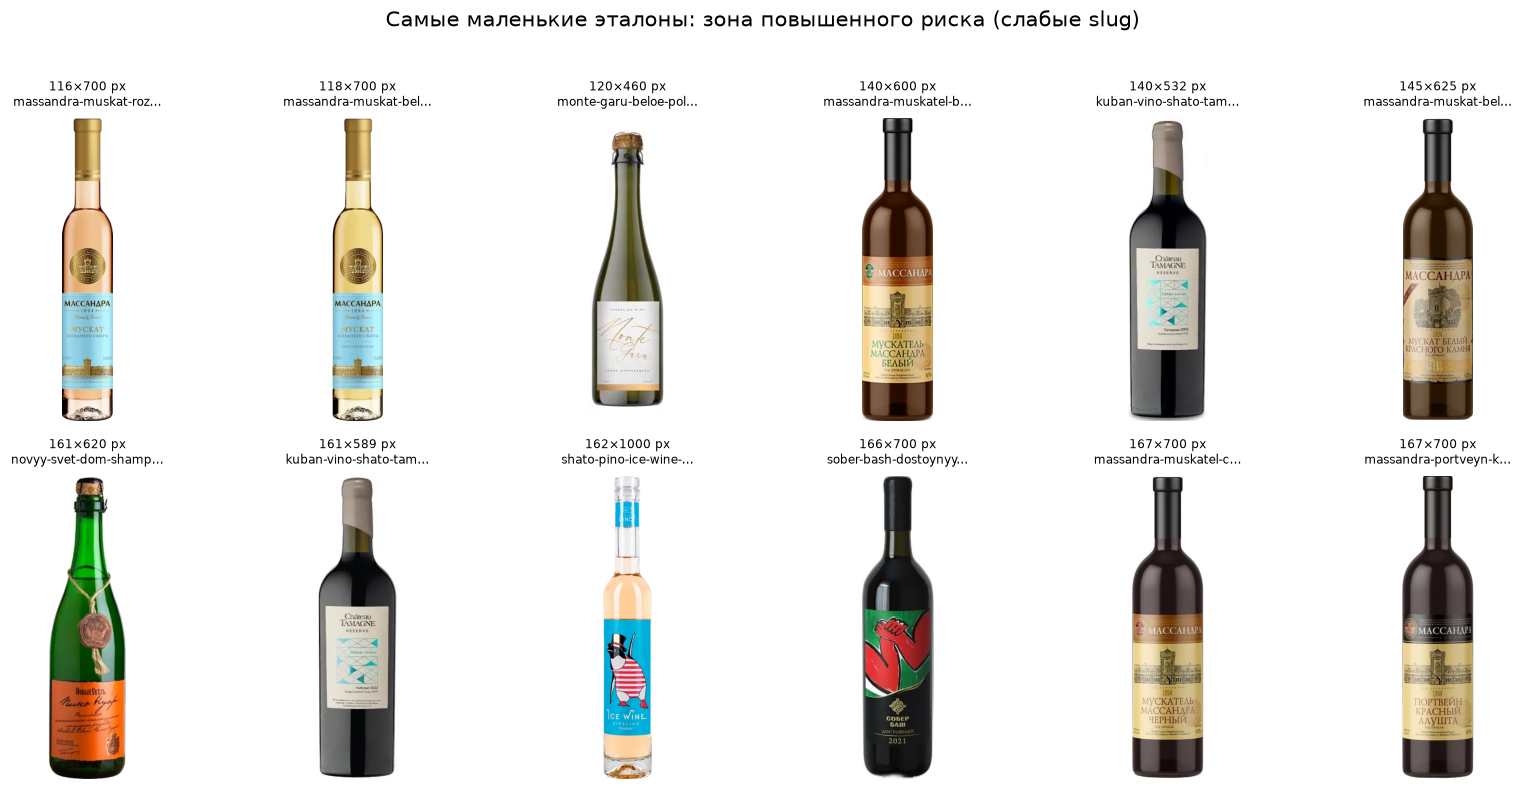

In [8]:
# Ищем 12 самых маленьких по ширине изображений
small = refs.nsmallest(12, 'width')

fig, axes = plt.subplots(2, 6, figsize=(16, 7))
axes = axes.flat

for axis, row in zip(axes, small.itertuples()):
    axis.imshow(load_image(image_path(row.slug)))
    axis.axis('off')
    
    # Сокращаем slug для аккуратного вывода
    slug_short = f"{row.slug[:20]}..." if len(row.slug) > 20 else row.slug
    axis.set_title(f'{row.width}×{row.height} px\n{slug_short}', fontsize=8, pad=8)

plt.suptitle('Самые маленькие эталоны: зона повышенного риска (слабые slug)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Выводы по качеству эталонов

1. **Ограничения пайплайна:** Маленькие и неоднородные эталоны становятся узким местом системы. Хотя модуль детекции (RT-DETR) и операции паддинга приводят пользовательский запрос и карточку к единому масштабу, они не способны "восстановить" детали, которых изначально нет. Если разрешение эталона слишком низкое, OCR физически не сможет прочитать текст на этикетке.
2. **Формирование слабых slug:** Товары с экстремально низким разрешением эталона (показанные на графике выше) — это и есть те самые **«слабые slug»**. Для них ломается механизм текстового различения (sibling guard). При встрече с пользовательской фотографией такого вина, система может ошибочно сматчить его с "соседом" по линейке просто потому, что не смогла прочитать различающие слова.
3. **Бизнес-задача:** Данный скрипт (сортировка по минимальной ширине/высоте) формирует готовый список (бэклог) для контент-менеджеров. Именно для этих позиций сейчас эффективнее всего собрать более качественные эталонные изображения, чтобы повысить общую точность системы.

## 4. Visual Retrieval и ближайшие соседи SigLIP 2

В этом разделе мы анализируем работу визуального энкодера (SigLIP 2), который отвечает за первый, грубый этап поиска. 

Чтобы оценить разделительную способность модели, мы извлекаем векторы всех эталонных изображений из FAISS-индекса и вычисляем матрицу косинусного сходства (cosine similarity). Задача — найти ближайшего визуального «соседа» для каждой карточки в базе и посмотреть, насколько сильно визуально сливаются разные товары.

Статистика косинусного сходства для ближайших соседей:


,Значение
count,2103.000000
mean,0.892415
std,0.065240
min,0.597475
25%,0.853563
50%,0.902609
75%,0.940570
max,1.000000


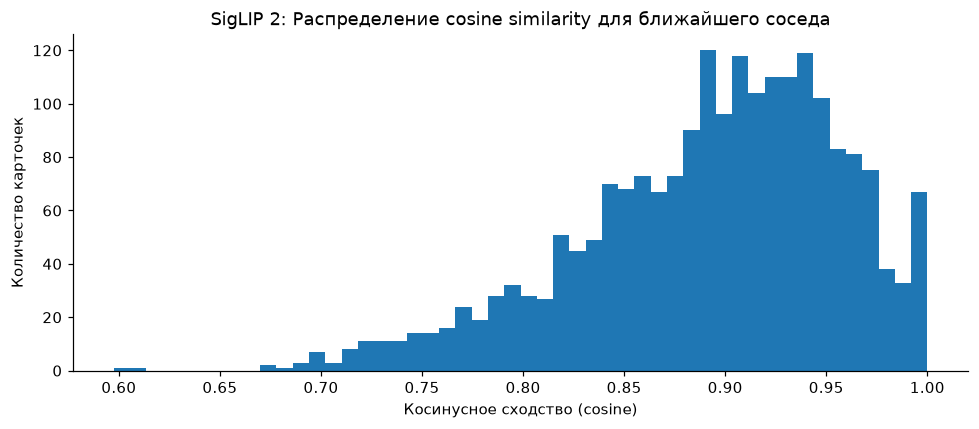

In [9]:
# Загрузка векторного индекса
index = VectorIndex.load(ROOT / 'models/index_platform_sq_v3')
vectors = index.index.reconstruct_n(0, index.index.ntotal)
ids = np.array(index.item_ids)

# Вычисление матрицы косинусного сходства (каждый с каждым)
similarity = vectors @ vectors.T

# Исключаем сходство карточки с самой собой (заполняем диагональ -1)
np.fill_diagonal(similarity, -1) 

# Поиск ближайшего соседа для каждого slug
nearest_index = similarity.argmax(axis=1)
nearest = pd.DataFrame({
    'slug': ids, 
    'nearest_slug': ids[nearest_index],
    'cosine': similarity.max(axis=1)
})

print("Статистика косинусного сходства для ближайших соседей:")
display(nearest.cosine.describe().to_frame('Значение'))

# Настройка визуализации
plt.figure(figsize=(9, 4))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Построение гистограммы
nearest.cosine.plot.hist(bins=50, color='#1f77b4')
plt.title('SigLIP 2: Распределение cosine similarity для ближайшего соседа')
plt.xlabel('Косинусное сходство (cosine)')
plt.ylabel('Количество карточек')

plt.tight_layout()
plt.show()

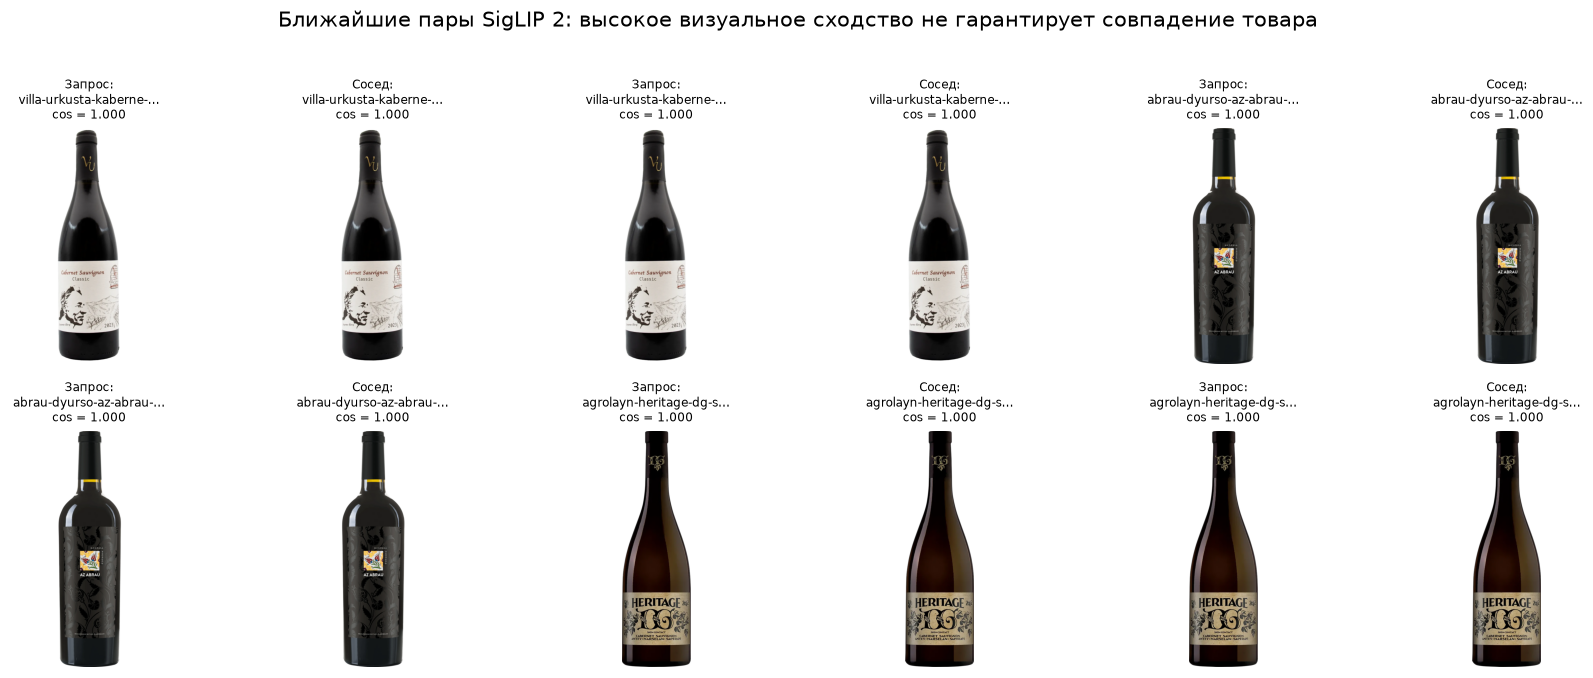

In [10]:
# Отбираем 6 пар с максимальным визуальным сходством (самые сложные кейсы)
top_pairs = nearest.nlargest(6, 'cosine')

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.flat

for pair_number, row in enumerate(top_pairs.itertuples()):
    for offset, slug in enumerate((row.slug, row.nearest_slug)):
        axis = axes[pair_number * 2 + offset]
        
        if image_path(slug).exists(): 
            axis.imshow(load_image(image_path(slug)))
            
        axis.axis('off')
        
        # Сокращаем slug для опрятности вывода
        slug_short = f"{slug[:22]}..." if len(slug) > 22 else slug
        label = 'Запрос' if offset == 0 else 'Сосед'
        axis.set_title(f"{label}:\n{slug_short}\ncos = {row.cosine:.3f}", fontsize=8, pad=6)

plt.suptitle('Ближайшие пары SigLIP 2: высокое визуальное сходство не гарантирует совпадение товара', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Выводы по визуальному поиску (Visual Retrieval)

1. **Роль эмбеддингов в архитектуре:** Модель SigLIP 2 эффективно решает задачу первого этапа — обеспечивает высокий recall. Она за доли секунды отсеивает тысячи нерелевантных позиций и сужает область поиска до компактного списка кандидатов.
2. **Интерпретация метрики:** Косинусное сходство — это сильный сигнал визуального сходства дизайна, а не вероятность правильного ответа. Как видно на примерах выше, у родственных вин (sibling-линеек) значение `cosine` может стремиться к единице, хотя физически это разные товары (разный винтаж, другой сорт).
3. **Обоснование механизма отказа (Fallback/Open-world):** Именно из-за высоких скоров у ложных визуальных близнецов мы не можем принимать решение только по эмбеддингам. Визуальная ветка поставляет кандидатов, а финальное решение (сматчить карточку или выдать честный отказ для неизвестного open-world вина) делегируется модели CatBoost. Она анализирует жесткие признаки: совпадение текстовых токенов (OCR PaddleOCR) и геометрическое соответствие (XFeat/RANSAC), что позволяет надежно разделять похожие дизайны.

## 5. Данные оценки и защита от утечки

В этом разделе мы проверяем распределение данных между обучающей (Train) и отложенной (Test/Holdout) выборками. 
Особое внимание уделяется проверке на утечку данных (Data Leakage) — ни один кадр не должен случайно попасть в обе выборки. Также мы оцениваем долю позиций без привязки к каталогу (true_slug is NaN), на которых тестируется важнейший архитектурный механизм — **отказ для open-world** (умение системы сказать «я не знаю это вино», а не выдавать ложноположительный результат).

,Кадры,Уникальные вина,Неизвестные (Open-world)
Выборка,,,
Train (обучение),432,232,242
Test (Holdout),225,106,114


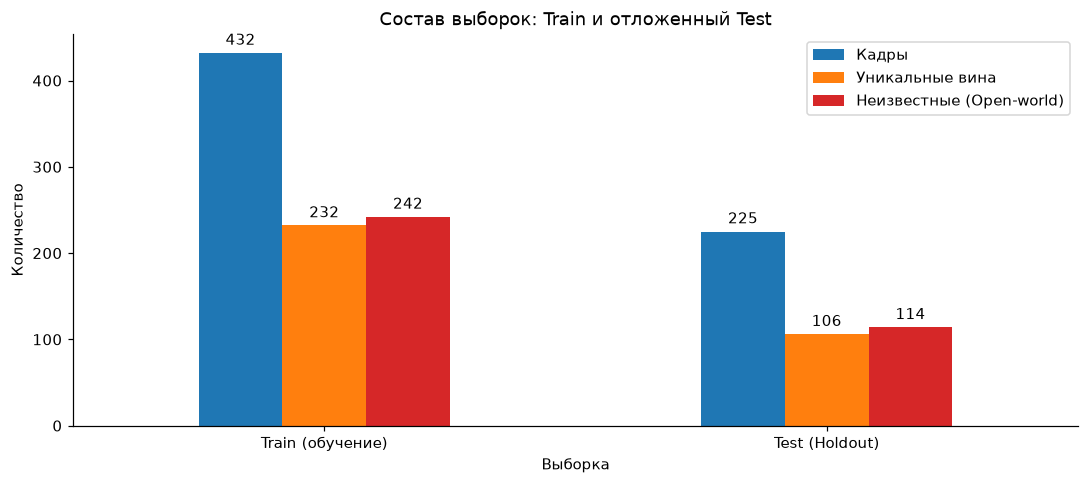

In [11]:
# Загрузка манифестов
train = pd.read_csv(ROOT / 'data/train/manifest.csv')
test = pd.read_csv(ROOT / 'data/test/manifest.csv')

# Формирование сводной таблицы
split = pd.DataFrame([
    {'Выборка': 'Train (обучение)', 
     'Кадры': len(train), 
     'Уникальные вина': train.wine_id.nunique(),
     'Неизвестные (Open-world)': train.true_slug.isna().sum()},
    {'Выборка': 'Test (Holdout)', 
     'Кадры': len(test), 
     'Уникальные вина': test.wine_id.nunique(),
     'Неизвестные (Open-world)': test.true_slug.isna().sum()},
])
display(split.set_index('Выборка'))

# ЖЕСТКАЯ ПРОВЕРКА НА УТЕЧКУ ДАННЫХ (Data Leakage)
assert set(train.path).isdisjoint(test.path), 'КРИТИЧЕСКАЯ ОШИБКА: Обнаружено пересечение файлов между train и test!'

# Настройка визуализации
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ax = split.set_index('Выборка')[['Кадры', 'Уникальные вина', 'Неизвестные (Open-world)']].plot.bar(
    figsize=(10, 4.5), 
    color=['#1f77b4', '#ff7f0e', '#d62728'],
    title='Состав выборок: Train и отложенный Test'
)
plt.xticks(rotation=0)
plt.ylabel('Количество')

# Добавление значений над столбцами
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

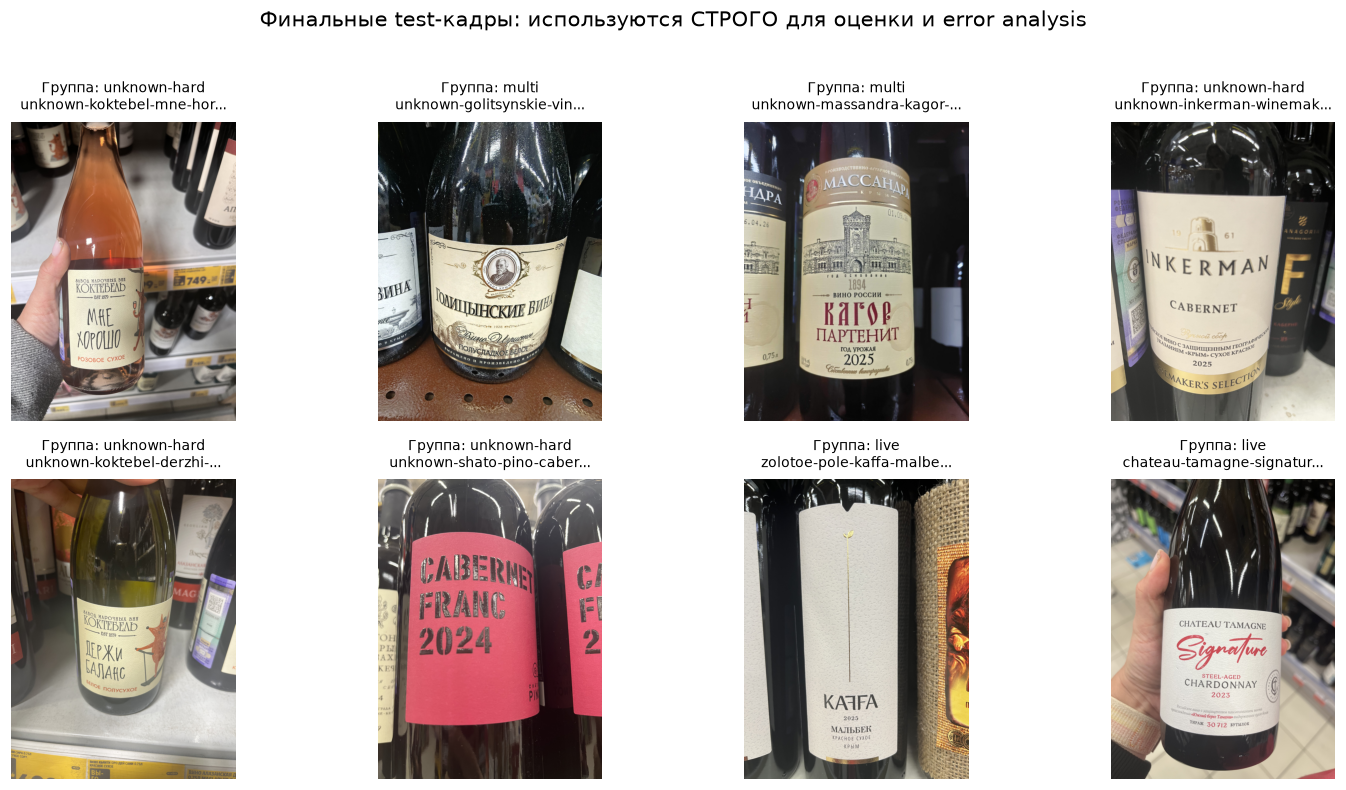

In [12]:
# Случайная выборка для визуальной проверки (фиксируем random_state для воспроизводимости)
sample = test.sample(min(8, len(test)), random_state=2026)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flat

for axis, row in zip(axes, sample.itertuples()):
    path = ROOT / row.path
    if path.exists(): 
        axis.imshow(load_image(path))
    axis.axis('off')
    
    # Сокращаем wine_id, чтобы текст не вылезал за границы
    wine_id_short = f"{row.wine_id[:24]}..." if isinstance(row.wine_id, str) and len(row.wine_id) > 24 else row.wine_id
    axis.set_title(f"Группа: {row.group}\n{wine_id_short}", fontsize=9, pad=8)

plt.suptitle('Финальные test-кадры: используются СТРОГО для оценки и error analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Выводы по тестированию и сбору данных

1. **Неприкосновенность Holdout:** Отложенный test (фотографии, сделанные нами самостоятельно) — это единственный инструмент честной оценки качества. На этих данных **категорически запрещены** обучение, подбор гиперпараметров (порогов CatBoost) и feature selection. Итоговая метрика должна отвечать на вопрос «как система работает с новыми пользовательскими фото», а не «насколько хорошо она запомнила выборку».
2. **Риск Overfitting на уровне аналитики:** Мы можем и должны визуализировать ошибки на holdout-сете (error analysis), чтобы понимать слабые места пайплайна. Но если мы начнем писать эвристики и править код, оглядываясь на эти конкретные ошибки, наш test быстро деградирует и превратится в часть обучающей выборки.
3. **Потребность в новых данных:** Именно поэтому самая полезная инвестиция сейчас — сбор **новой независимой validation-группы из реальных, ранее не встречавшихся вин**. 
   * Во-первых, это позволит нам проводить тюнинг пайплайна, сохраняя текущий holdout в чистоте. 
   * Во-вторых, свежий поток незнакомых бутылок критически необходим для калибровки механизма отказа (open-world rejection), чтобы система училась уверенно отклонять неизвестное, а не пыталась притянуть за уши ближайшего соседа из базы.

## Итог EDA

1. Каталог определяет архитектуру:

- Поиск (retrieval) вместо классификации: мы ищем похожие товары в базе, а не пытаемся жестко распределить их по заранее заданным классам.

- Текстовые признаки: используем текст, чтобы система могла отличить похожие вина из одной линейки (sibling-линейки).

- Механизм отказа: если система видит совершенно незнакомое вино, она выдает отказ, а не пытается угадать.

2. Приоритеты по сбору данных:

- Нужны качественные эталонные примеры для проблемных товаров (слабых slug), которые сейчас распознаются хуже всего.

- Нужна новая, полностью независимая валидационная выборка из реальных вин, которые система еще не видела.